In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import random
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [2]:
os.chdir('/workspaces/xitaso/data')

In [15]:
ROOT_FOLDER = os.path.dirname(os.getcwd())
PROCESSED_DATA =  os.path.join(ROOT_FOLDER, "data","processed")

In [16]:
ICU_STAYS = os.path.join(PROCESSED_DATA,"icustays_20240512.feather")
ICU_TIMESERIES_FEATURES = os.path.join(PROCESSED_DATA,"icu_timeseries_features_0M_0ed859c799267d4ae737f8814d52726d_20240512.feather")
ICU_OUTPUT_EVENTS = os.path.join(PROCESSED_DATA,"icu_outputevents_0M_0ed859c799267d4ae737f8814d52726d_20240512.feather")
icu_stays_df = pd.read_feather(ICU_STAYS)
icu_timeseries_features_df = pd.read_feather(ICU_TIMESERIES_FEATURES)
icu_output_events_df = pd.read_feather(ICU_OUTPUT_EVENTS)

In [17]:
icu_stays_df.head()

,subject_id,hadm_id,icu_stay_id,first_careunit,icu_intime,icu_outtime,icu_los,hours_until_readmission,will_be_readmitted,hours_to_readmission,stay_is_readmission
0,10018328,23786647,31269608,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512,NaN,False,NaN,False
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662,NaN,False,NaN,False
2,10020187,26842957,32554129,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685,NaN,False,NaN,False
3,10012853,27882036,31338022,Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725,NaN,False,NaN,False
4,10020740,25826145,32145159,Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106,NaN,False,NaN,False


In [18]:
icu_timeseries_features_df.head()

,abs_event_time,stay_id,Activity / Mobility (JH-HLM),Apnea Interval,Arterial Blood Pressure Alarm - High,Arterial Blood Pressure Alarm - Low,Arterial Blood Pressure diastolic,Arterial Blood Pressure mean,Arterial Blood Pressure systolic,Current Dyspnea Assessment,...,RDW-SD,Red Blood Cells,Sodium,"Sodium, Whole Blood",Temperature,Urea Nitrogen,White Blood Cells,pCO2,pH,pO2
0,1970-01-01 01:00:00,30057454,NaN,NaN,NaN,NaN,64.800000,75.0,96.800000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1970-01-01 02:00:00,30057454,NaN,NaN,NaN,NaN,62.333333,72.0,93.333333,NaN,...,NaN,4.73,139.0,NaN,NaN,45.0,12.7,NaN,NaN,NaN
2,1970-01-01 03:00:00,30057454,NaN,NaN,NaN,NaN,64.000000,76.0,99.000000,NaN,...,NaN,4.73,139.0,NaN,NaN,45.0,12.7,45.0,7.4,76.0
3,1970-01-01 04:00:00,30057454,NaN,NaN,NaN,NaN,67.000000,78.0,102.000000,NaN,...,NaN,4.73,139.0,NaN,NaN,45.0,12.7,45.0,7.4,76.0
4,1970-01-01 05:00:00,30057454,NaN,NaN,NaN,NaN,67.000000,79.0,105.000000,NaN,...,NaN,4.73,139.0,NaN,NaN,45.0,12.7,45.0,7.4,76.0


In [19]:
icu_output_events_df.head()

,stay_id,urine_last_1d
0,30057454,1621
1,30101877,1857
2,30425410,1070
3,30458995,1760
4,30585761,2010


In [20]:
icu_stays_df['stay_id'] = icu_stays_df['icu_stay_id']
icu_stays_df.head()

,subject_id,hadm_id,icu_stay_id,first_careunit,icu_intime,icu_outtime,icu_los,hours_until_readmission,will_be_readmitted,hours_to_readmission,stay_is_readmission,stay_id
0,10018328,23786647,31269608,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512,NaN,False,NaN,False,31269608
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662,NaN,False,NaN,False,37509585
2,10020187,26842957,32554129,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685,NaN,False,NaN,False,32554129
3,10012853,27882036,31338022,Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725,NaN,False,NaN,False,31338022
4,10020740,25826145,32145159,Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106,NaN,False,NaN,False,32145159


In [21]:
# Create 'readmitted' column based on 'hours_until_readmission'
icu_stays_df['readmitted'] = icu_stays_df['hours_until_readmission'].apply(lambda x: 1 if x <= 720 else 0)
icu_stays_df['readmitted'] = icu_stays_df['readmitted'].fillna(0).astype(int)
icu_stays_df[['subject_id','stay_id','hours_until_readmission', 'readmitted', 'will_be_readmitted']].head()

,subject_id,stay_id,hours_until_readmission,readmitted,will_be_readmitted
0,10018328,31269608,NaN,0,False
1,10020187,37509585,NaN,0,False
2,10020187,32554129,NaN,0,False
3,10012853,31338022,NaN,0,False
4,10020740,32145159,NaN,0,False


In [22]:
# Select only the required columns from icu_stays_df
icu_stays_df = icu_stays_df[['subject_id', 'stay_id', 'readmitted', 'icu_intime' , 'icu_outtime' , 'will_be_readmitted']]

# Ensure 'stay_id' is of type int64 in both DataFrames
icu_stays_df['stay_id'] = icu_stays_df['stay_id'].astype('int64')
icu_timeseries_features_df['stay_id'] = icu_timeseries_features_df['stay_id'].astype('int64')

merged_df = pd.merge(icu_stays_df,icu_timeseries_features_df, on='stay_id')
merged_df.head()

,subject_id,stay_id,readmitted,icu_intime,icu_outtime,will_be_readmitted,abs_event_time,Activity / Mobility (JH-HLM),Apnea Interval,Arterial Blood Pressure Alarm - High,...,RDW-SD,Red Blood Cells,Sodium,"Sodium, Whole Blood",Temperature,Urea Nitrogen,White Blood Cells,pCO2,pH,pO2
0,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 01:00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 02:00:00,1.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN
2,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 03:00:00,1.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN
3,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 04:00:00,1.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN
4,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 05:00:00,1.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN


In [23]:
merged_df = pd.merge(merged_df , icu_output_events_df, on='stay_id')
merged_df.head()

,subject_id,stay_id,readmitted,icu_intime,icu_outtime,will_be_readmitted,abs_event_time,Activity / Mobility (JH-HLM),Apnea Interval,Arterial Blood Pressure Alarm - High,...,Red Blood Cells,Sodium,"Sodium, Whole Blood",Temperature,Urea Nitrogen,White Blood Cells,pCO2,pH,pO2,urine_last_1d
0,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 01:00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2130
1,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 02:00:00,1.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,2130
2,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 03:00:00,1.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,2130
3,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 04:00:00,1.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,2130
4,10018328,31269608,0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 05:00:00,1.0,NaN,180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,2130


In [24]:
print(merged_df.shape)

(2879, 111)


In [25]:
# Remove duplicate rows
merged_df = merged_df.drop_duplicates()
print(merged_df.shape)

(2879, 111)


In [26]:
distribution = merged_df['readmitted'].value_counts()
print(distribution)

readmitted
0    2451
1     428
Name: count, dtype: int64


In [27]:
#Convert datetime columns to datetime format
icu_stays_df['icu_intime'] = pd.to_datetime(icu_stays_df['icu_intime'])
icu_stays_df['icu_outtime'] = pd.to_datetime(icu_stays_df['icu_outtime'])

# Function to determine the ICU day based on user input date
def get_icu_day(subject_id, input_date):
    # Find the patient's ICU stay record
    patient_record = icu_stays_df[icu_stays_df['subject_id'] == subject_id]
    
    if patient_record.empty:
        return "Subject ID not found"
    
    intime = patient_record['icu_intime'].iloc[0]
    outtime = patient_record['icu_outtime'].iloc[0]
    
    if intime <= input_date <= outtime:
        icu_day = (input_date - intime).days + 1
        return icu_day
    else:
        return "Input date is outside the ICU stay period"

# Get user input for subject ID and date
subject_id = int(input("Enter subject ID: "))  # Example: 10020187

# Find the patient's ICU stay record to display the date range
patient_record = icu_stays_df[icu_stays_df['subject_id'] == subject_id]
if not patient_record.empty:
    intime = patient_record['icu_intime'].iloc[0]
    outtime = patient_record['icu_outtime'].iloc[0]
    print(f"Select a date between {intime.strftime('%Y-%m-%d')} and {outtime.strftime('%Y-%m-%d')}")
else:
    print("Subject ID not found")
    exit()

input_date_str = input("Enter date (YYYY-MM-DD): ")  # Example: 2169-01-16
input_date = datetime.strptime(input_date_str, "%Y-%m-%d")

icu_day = get_icu_day(subject_id, input_date)
print(f"ICU Day: {icu_day}")

Enter subject ID:  10018081


Select a date between 2134-08-05 and 2134-08-07


Enter date (YYYY-MM-DD):  2134-08-07


ICU Day: 2


In [28]:
# Calculate the percentage of NaN values for each column
nan_percentage = merged_df.isnull().mean()

# Set a threshold, for example, 90%
threshold = 0.85

# Identify columns to drop
columns_to_drop = nan_percentage[nan_percentage > threshold].index

# Drop these columns from the dataset
merged_df_cleaned = merged_df.drop(columns=columns_to_drop)

# Display the columns that were removed
removed_columns = columns_to_drop.tolist()
print("Removed columns:", removed_columns)

Removed columns: ['Height (cm)', 'H', 'Hematocrit, Calculated', 'I', 'L', 'Temperature']


In [29]:
distribution = merged_df_cleaned['readmitted'].value_counts()
print(distribution)

readmitted
0    2451
1     428
Name: count, dtype: int64


In [30]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Select only the columns to be imputed (all numeric columns in this example)
numeric_columns = merged_df_cleaned.select_dtypes(include=['float64', 'int64']).columns
numeric_data = merged_df_cleaned[numeric_columns]

# Initialize the MICE imputer with a specified number of iterations
mice_imputer = IterativeImputer(random_state=42, max_iter=20) 

# Apply the MICE imputer to the numeric data
imputed_numeric_data = mice_imputer.fit_transform(numeric_data)

# Convert the imputed data back to a DataFrame
imputed_numeric_df = pd.DataFrame(imputed_numeric_data, columns=numeric_columns)

# Replace the numeric columns in the original DataFrame with the imputed data
merged_df_cleaned[numeric_columns] = imputed_numeric_df

merged_df_cleaned.head()

,subject_id,stay_id,readmitted,icu_intime,icu_outtime,will_be_readmitted,abs_event_time,Activity / Mobility (JH-HLM),Apnea Interval,Arterial Blood Pressure Alarm - High,...,RDW-SD,Red Blood Cells,Sodium,"Sodium, Whole Blood",Urea Nitrogen,White Blood Cells,pCO2,pH,pO2,urine_last_1d
0,10018328.0,31269608.0,0.0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 01:00:00,1.76574,19.819851,140.666355,...,48.822102,3.555970,137.435120,136.531336,21.830347,14.502745,40.600466,6.749959,118.947978,2130.0
1,10018328.0,31269608.0,0.0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 02:00:00,1.00000,21.352861,180.000000,...,48.936778,3.551519,137.364570,136.340929,22.136451,10.710687,40.824777,6.000000,117.589784,2130.0
2,10018328.0,31269608.0,0.0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 03:00:00,1.00000,21.346406,180.000000,...,49.611064,3.562032,137.744203,136.636452,24.105752,10.490589,40.682384,6.000000,132.784394,2130.0
3,10018328.0,31269608.0,0.0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 04:00:00,1.00000,20.649428,180.000000,...,49.571002,3.545279,137.516838,136.341862,21.225324,9.987618,40.652474,6.000000,115.703253,2130.0
4,10018328.0,31269608.0,0.0,2154-04-24 23:03:44,2154-05-02 15:55:21,False,1970-01-01 05:00:00,1.00000,20.831187,180.000000,...,48.605119,3.538028,137.141744,135.877844,19.773509,10.902548,41.036550,6.000000,98.598306,2130.0


In [31]:
distribution = merged_df_cleaned['readmitted'].value_counts()
print(distribution)

readmitted
0.0    2451
1.0     428
Name: count, dtype: int64


Top features based on combined methods:
10                                Daily Weight
45                      Respiratory Rate (Set)
64             Asparate Aminotransferase (AST)
79                                        MCHC
67                            Bilirubin, Total
35                                   PSV Level
88                      Potassium, Whole Blood
0                                   subject_id
86                              Platelet Count
49                              Strength L Arm
95                           White Blood Cells
23                  Minute Volume Alarm - High
1                                      stay_id
28    Non-Invasive Blood Pressure Alarm - High
78                                         MCH
63                                   Anion Gap
60                                Braden Score
36                                  Pain Level
55                          Tidal Volume (set)
68                              Calcium, Total
77                  

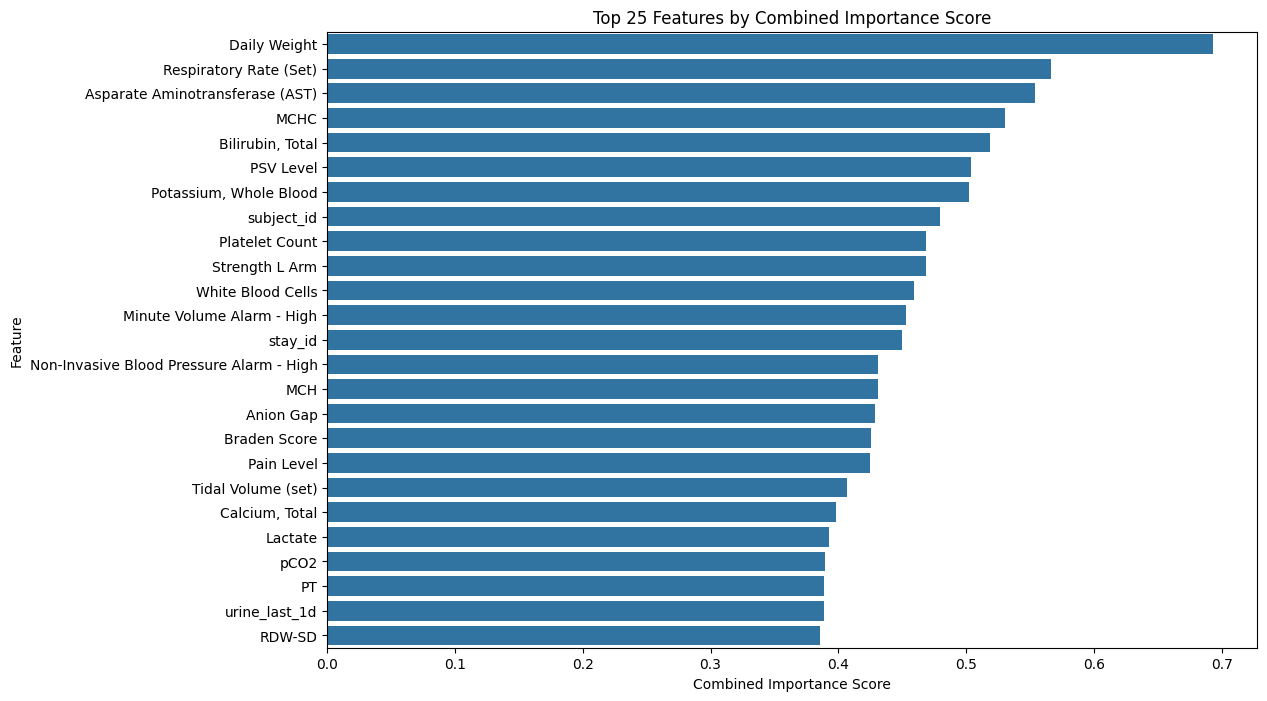

In [32]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import seaborn as sns


# Define features and target variable
X = merged_df_cleaned.drop(['readmitted'], axis=1)
y = merged_df_cleaned['readmitted']

# Handle imbalanced classes by oversampling the minority class
df_majority = merged_df_cleaned[merged_df_cleaned.readmitted == 0]
df_minority = merged_df_cleaned[merged_df_cleaned.readmitted == 1]

if len(df_minority) > 0: 
    df_minority_upsampled = resample(df_minority,
                                     replace=True,     # sample with replacement
                                     n_samples=len(df_majority),    # to match majority class
                                     random_state=42) # reproducible results

    # Combine majority class with upsampled minority class
    df_upsampled = pd.concat([df_majority, df_minority_upsampled])

    # Separate features and target variable again
    X_upsampled = df_upsampled.drop(['readmitted'], axis=1)
    y_upsampled = df_upsampled['readmitted']

    # Select only numeric columns for model training
    numeric_X = X_upsampled.select_dtypes(include=['float64', 'int64'])

    # Standardize the features
    scaler = StandardScaler()
    numeric_X_scaled = scaler.fit_transform(numeric_X)

    # RandomForest Feature Importance
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(numeric_X_scaled, y_upsampled)
    rf_importances = rf_model.feature_importances_

    # RFE
    rfe = RFE(estimator=rf_model, n_features_to_select=25, step=1)
    rfe.fit(numeric_X_scaled, y_upsampled)
    rfe_ranking = rfe.ranking_

    # Logistic Regression with L1 penalty
    log_reg = LogisticRegressionCV(cv=5, penalty='l1', solver='liblinear', random_state=42, max_iter=1000)
    log_reg.fit(numeric_X_scaled, y_upsampled)
    log_reg_coef = np.abs(log_reg.coef_[0])  # Taking absolute to get magnitude

    # Create a DataFrame for all feature scores
    features = numeric_X.columns
    scores_df = pd.DataFrame({
        'Feature': features,
        'RandomForest': rf_importances,
        'RFE': 1 / rfe_ranking,  # Inverse ranking, lower rank gets higher importance
        'Logistic_L1': log_reg_coef
    })

    # Normalize the scores
    scores_df['RandomForest'] = scores_df['RandomForest'] / scores_df['RandomForest'].max()
    scores_df['RFE'] = scores_df['RFE'] / scores_df['RFE'].max()
    scores_df['Logistic_L1'] = scores_df['Logistic_L1'] / scores_df['Logistic_L1'].max()

    # Aggregate the normalized scores
    scores_df['CombinedScore'] = scores_df[['RandomForest', 'RFE', 'Logistic_L1']].mean(axis=1)

    # Sort by the combined score
    scores_df = scores_df.sort_values(by='CombinedScore', ascending=False)

    # Select top features
    top_features_combined = scores_df.head(25)['Feature']

    print("Top features based on combined methods:")
    print(top_features_combined)

    # Plotting the combined feature importances
    plt.figure(figsize=(12, 8))
    sns.barplot(x='CombinedScore', y='Feature', data=scores_df.head(25))
    plt.title('Top 25 Features by Combined Importance Score')
    plt.xlabel('Combined Importance Score')
    plt.ylabel('Feature')
    plt.show()
else:
    print("The dataset does not contain enough samples of the minority class.")


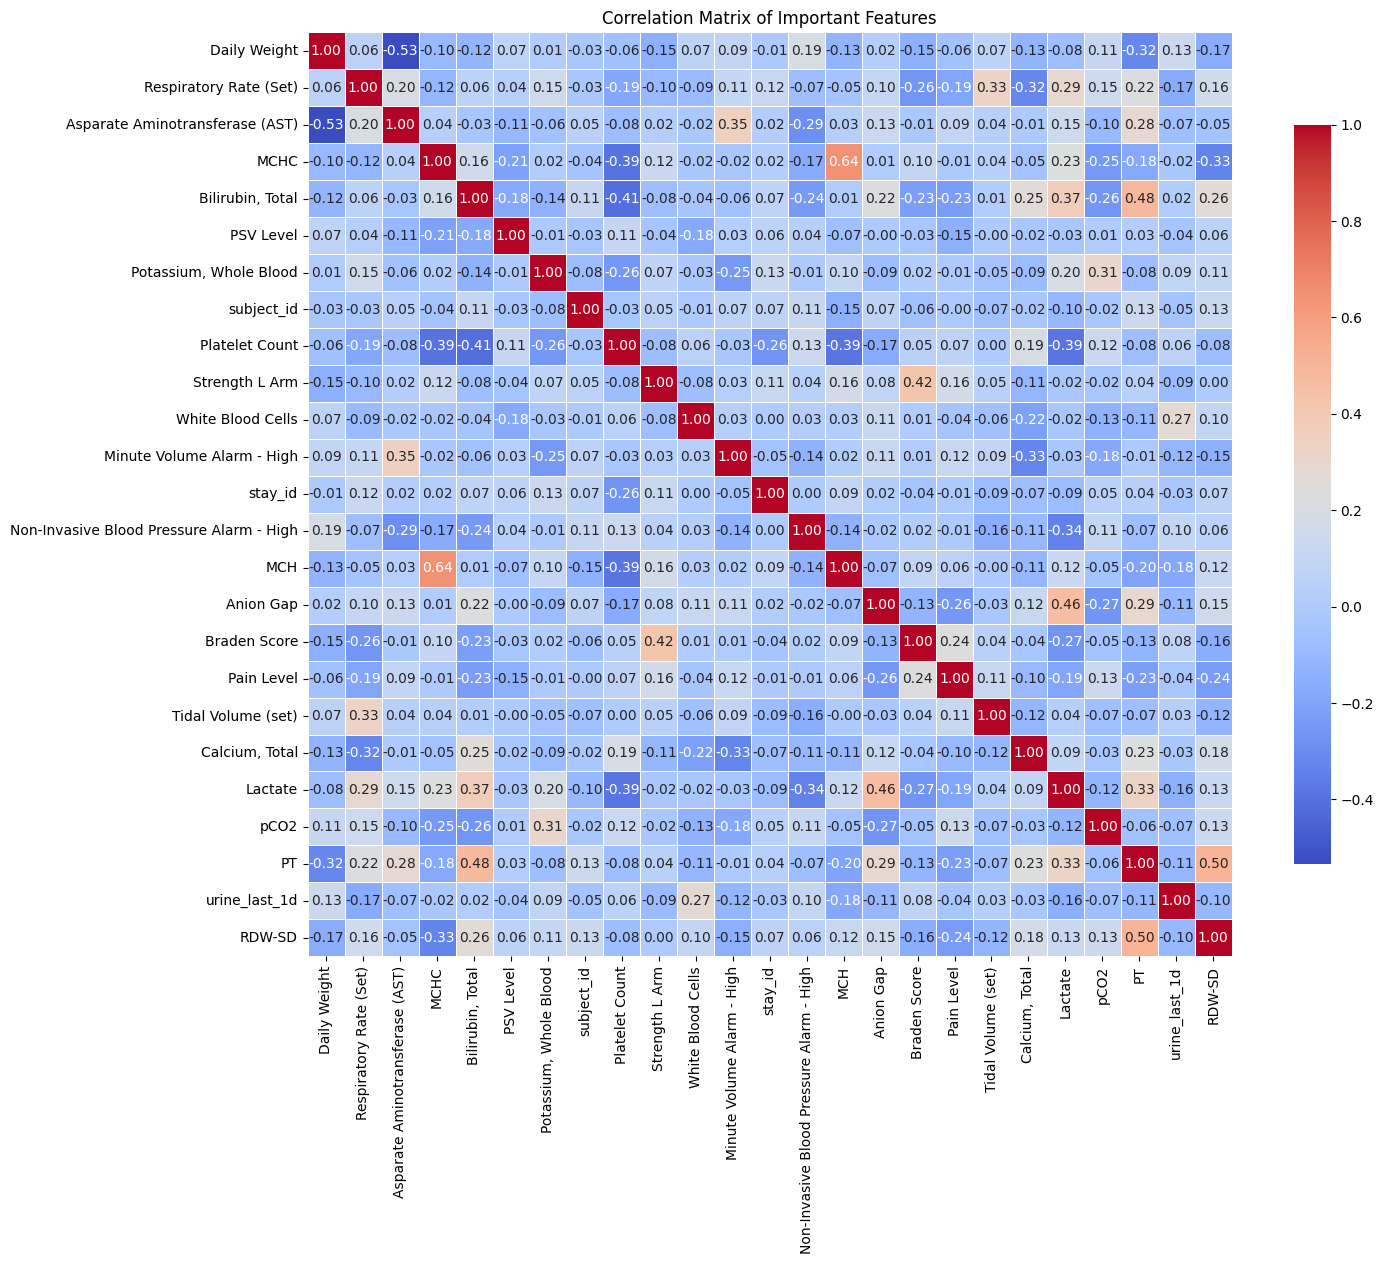

In [28]:
# Filter the dataset to only include these important features
X_important_features = merged_df_cleaned[top_features_combined]

# Calculate the correlation matrix
correlation_matrix = X_important_features.corr()

plt.figure(figsize=(16, 12))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Correlation Matrix of Important Features')
plt.show()

In [33]:
# Split the data into 70% training and 30% remaining (cross validation + test)
train_df, remaining_df = train_test_split(merged_df_cleaned, test_size=0.30, random_state=42)

# Split the remaining data into 50% cross validation and 50% test
cross_val_df, test_df = train_test_split(remaining_df, test_size=0.50, random_state=42)

# Check the size of each set
print(f"Training set size: {len(train_df)}")
print(f"Cross Validation set size: {len(cross_val_df)}")
print(f"Test set size: {len(test_df)}")

# Show the distribution of 'readmitted' in each set
print("Training set 'readmitted' distribution:")
print(train_df['readmitted'].value_counts(normalize=True))

print("Cross Validation set 'readmitted' distribution:")
print(cross_val_df['readmitted'].value_counts(normalize=True))

print("Test set 'readmitted' distribution:")
print(test_df['readmitted'].value_counts(normalize=True))

# Save the resulting DataFrames to CSV files
train_output_path = 'train_data.csv'
cross_val_output_path = 'cross_val_data.csv'
test_output_path = 'test_data.csv'

train_df.to_csv(train_output_path, index=False)
cross_val_df.to_csv(cross_val_output_path, index=False)
test_df.to_csv(test_output_path, index=False)



Training set size: 2015
Cross Validation set size: 432
Test set size: 432
Training set 'readmitted' distribution:
readmitted
0.0    0.848139
1.0    0.151861
Name: proportion, dtype: float64
Cross Validation set 'readmitted' distribution:
readmitted
0.0    0.863426
1.0    0.136574
Name: proportion, dtype: float64
Test set 'readmitted' distribution:
readmitted
0.0    0.854167
1.0    0.145833
Name: proportion, dtype: float64


Test Set Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99       369
         1.0       1.00      0.94      0.97        63

    accuracy                           0.99       432
   macro avg       0.99      0.97      0.98       432
weighted avg       0.99      0.99      0.99       432

Test Set Accuracy: 0.9907407407407407
Test Set ROC AUC: 0.9999139673936422
Validation Set Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00       373
         1.0       1.00      0.95      0.97        59

    accuracy                           0.99       432
   macro avg       1.00      0.97      0.98       432
weighted avg       0.99      0.99      0.99       432

Validation Set Accuracy: 0.9930555555555556
Validation Set ROC AUC: 0.9998182396510201


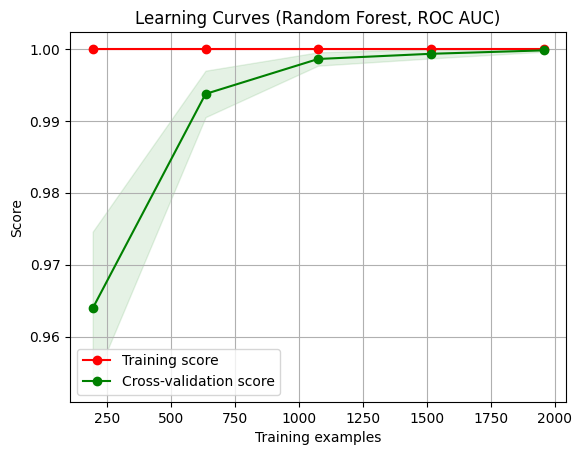

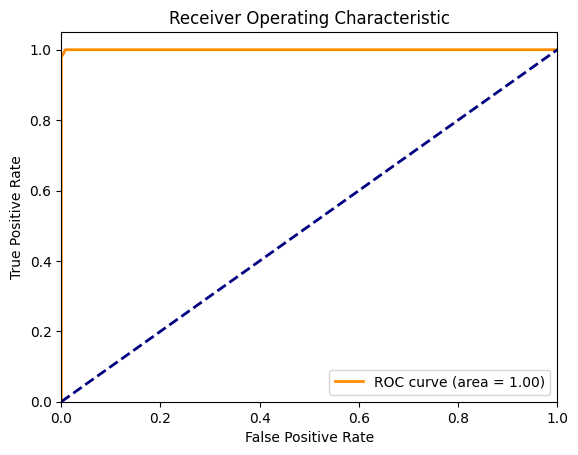

In [41]:
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve, auc
import joblib

# Define important features
important_features = [
    'Daily Weight' , 'Respiratory Rate (Set)', 'Asparate Aminotransferase (AST)', 'MCHC', 'Bilirubin, Total',
    'PSV Level', 'Potassium, Whole Blood', 'Platelet Count', 'Strength L Arm', 'White Blood Cells',
    'Minute Volume Alarm - High', 'Non-Invasive Blood Pressure Alarm - High', 'Anion Gap', 'Braden Score', 'Glucose' ,
    'Pain Level', 'Tidal Volume (set)', 'Calcium, Total', 'Lactate', 'pCO2', 'PT', 'urine_last_1d' , 'GCS - Verbal Response' 
]

# Define features (X) and target variable (y)
X_train = train_df[important_features]
y_train = train_df['readmitted']

X_val = cross_val_df[important_features]
y_val = cross_val_df['readmitted']

X_test = test_df[important_features]
y_test = test_df['readmitted']

# Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Save the trained model
joblib.dump(rf_model, 'random_forest_model_timeseries.pkl')

# Make predictions on the test set
y_pred_test = rf_model.predict(X_test)
y_prob_test = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model on the test set
print("Test Set Classification Report:")
print(classification_report(y_test, y_pred_test))
print(f"Test Set Accuracy: {accuracy_score(y_test, y_pred_test)}")
print(f"Test Set ROC AUC: {roc_auc_score(y_test, y_prob_test)}")

# Make predictions on the validation set
y_pred_val = rf_model.predict(X_val)
y_prob_val = rf_model.predict_proba(X_val)[:, 1]

# Evaluate the model on the validation set
print("Validation Set Classification Report:")
print(classification_report(y_val, y_pred_val))
print(f"Validation Set Accuracy: {accuracy_score(y_val, y_pred_val)}")
print(f"Validation Set ROC AUC: {roc_auc_score(y_val, y_prob_val)}")

# Get the feature importances
feature_importances = rf_model.feature_importances_

# Create a DataFrame for feature importances
features_df = pd.DataFrame({
    'Feature': important_features,
    'Importance': feature_importances
})

# Sort the DataFrame by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Function to plot the learning curve
def plot_learning_curve(estimator, title, X, y, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure()
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='roc_auc')
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

# Plot learning curve
title = "Learning Curves (Random Forest, ROC AUC)"
cv = StratifiedKFold(n_splits=5)  # 5-fold cross-validation
estimator = rf_model
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

plot_learning_curve(estimator, title, X_train_full, y_train_full, cv=cv, n_jobs=-1)

plt.show()

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
